### Normal Distributions

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
dataset = pd.read_csv("PrePlacement.csv")

In [3]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [4]:
dataset.isna().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [5]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

<Axes: xlabel='ssc_p', ylabel='Count'>

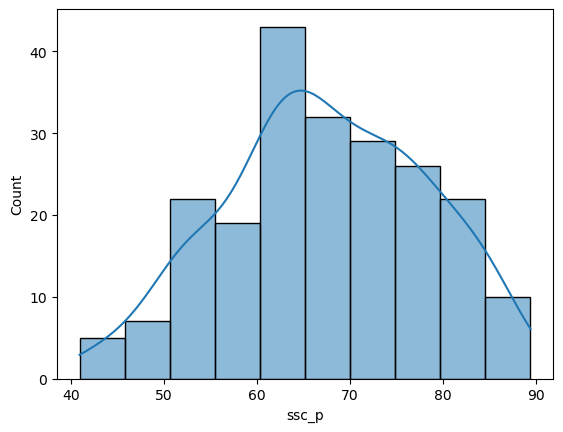

In [6]:
# sns.distplot(dataset["ssc_p"])
sns.histplot(dataset["ssc_p"], kde=True)

In [7]:
def get_pdf_probability(dataset, startrange, endrange):

    from matplotlib import pyplot as plt
    from scipy.stats import norm
    import seaborn as sns

    # Plot histogram with KDE
    sns.histplot(dataset, kde=True, line_kws={'color': 'blue'}, color='green')

    plt.axvline(startrange, color='red')
    plt.axvline(endrange, color='red')
    plt.show()

    # Calculate mean and std
    sample_mean = dataset.mean()
    sample_std = dataset.std()

    print(f"Mean = {sample_mean:.3f}")
    print(f"Standard Deviation = {sample_std:.3f}")

    # Define normal distribution
    dist = norm(sample_mean, sample_std)

    # Probability between start and end range
    probability = dist.cdf(endrange) - dist.cdf(startrange)

    print(f"Probability between range ({startrange}, {endrange}): {probability:.4f}")

    return probability

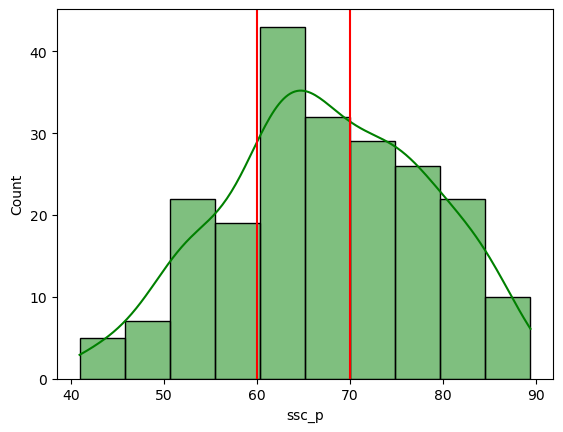

Mean = 67.303
Standard Deviation = 10.827
Probability between range (60, 70): 0.3484


np.float64(0.34835845838786206)

In [8]:
get_pdf_probability(dataset["ssc_p"], 60, 70)

In [9]:
# 34.84% of the data covered between 60 - 70 marks
# There are 34.84% of chances to getting 60 - 70 marks

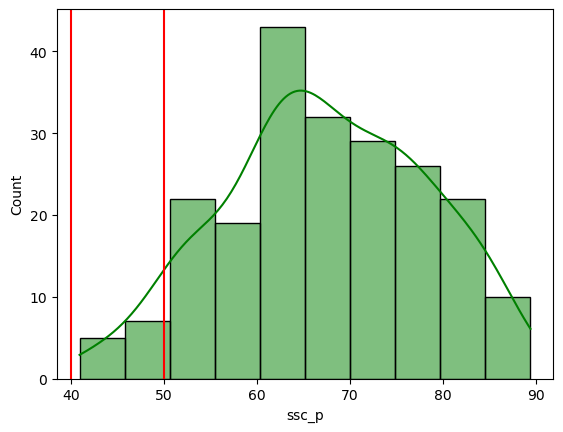

Mean = 67.303
Standard Deviation = 10.827
Probability between range (40, 50): 0.0492


np.float64(0.04916705533695259)

In [10]:
get_pdf_probability(dataset["ssc_p"], 40, 50)

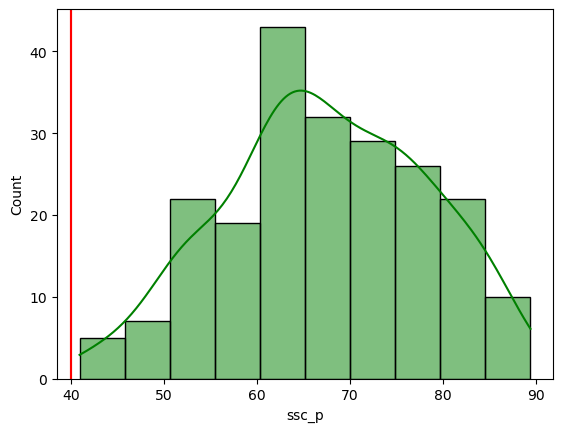

Mean = 67.303
Standard Deviation = 10.827
Probability between range (40, 40): 0.0000


np.float64(0.0)

In [11]:
get_pdf_probability(dataset["ssc_p"], 40, 40)
# PDF = talks about the gap between two boundaries

In [12]:
# Empirical Cumulative Distribution Function (ECDF)

In [13]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(dataset["ssc_p"])

ecdf(78)
print(ecdf(78))

0.827906976744186


In [19]:
def standard_normal_distribution_graph(dataset):
	import seaborn as sns
	
	mean = dataset.mean()
	std = dataset.std()
	
	values = [i for i in dataset]
	z_score = [((value - mean)/std) for value in values]
	
	sns.histplot(z_score, kde=True)
	
	sum(z_score)/len(z_score)

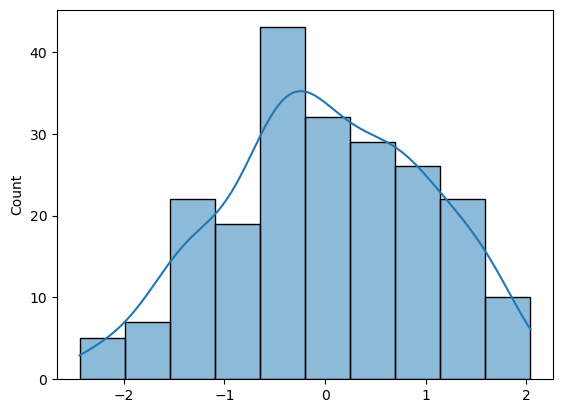

In [20]:
standard_normal_distribution_graph(dataset["ssc_p"])